# Benchmark Evaluation: LCC-FASD Dataset
Evaluate Silent-FAS pipeline on LCC-FASD evaluation set (7,580 images).

In [1]:
import os
import sys
import cv2
import numpy as np
from tqdm import tqdm

fas_root = os.path.abspath("../third_party/Silent-Face-Anti-Spoofing")
sys.path.insert(0, fas_root)
os.chdir(fas_root)

from src.anti_spoof_predict import AntiSpoofPredict

predictor = AntiSpoofPredict(device_id=0)
model_dir = "resources/anti_spoof_models"
model_paths = sorted([os.path.join(model_dir, f) for f in os.listdir(model_dir) if f.endswith(".pth")])

In [2]:
eval_root = os.path.abspath("../../data/raw/LCC_FASD/LCC_FASD_evaluation")
real_dir = os.path.join(eval_root, "real")
spoof_dir = os.path.join(eval_root, "spoof")

labels = []
scores = []

# Evaluate real images
real_files = sorted(os.listdir(real_dir))
for fname in tqdm(real_files, desc="Real"):
    img = cv2.imread(os.path.join(real_dir, fname))
    if img is None:
        continue
    try:
        bbox = predictor.get_bbox(img)
        x, y, w, h = bbox
        face = cv2.resize(img[y:y+h, x:x+w], (80, 80))
        total = 0.0
        for path in model_paths:
            result = predictor.predict(face, path)
            total += result[0][1]
        score = total / len(model_paths)
        labels.append(1)
        scores.append(score)
    except:
        continue

# Evaluate spoof images
spoof_files = sorted(os.listdir(spoof_dir))
for fname in tqdm(spoof_files, desc="Spoof"):
    img = cv2.imread(os.path.join(spoof_dir, fname))
    if img is None:
        continue
    try:
        bbox = predictor.get_bbox(img)
        x, y, w, h = bbox
        face = cv2.resize(img[y:y+h, x:x+w], (80, 80))
        total = 0.0
        for path in model_paths:
            result = predictor.predict(face, path)
            total += result[0][1]
        score = total / len(model_paths)
        labels.append(0)
        scores.append(score)
    except:
        continue

labels = np.array(labels)
scores = np.array(scores)
print(f"Evaluated: {len(labels)} images ({(labels==1).sum()} real, {(labels==0).sum()} spoof)")

Real:   0%|          | 0/314 [00:00<?, ?it/s]c:\Users\gmission\Desktop\face-defense\third_party\Silent-Face-Anti-Spoofing\src\anti_spoof_predict.py:91: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  result = F.softmax(result).cpu().numpy()
Spoof: 100%|██████████| 7266/7266 [17:27<00:00,  6.94it/s]

Evaluated: 7577 images (314 real, 7263 spoof)


In [3]:
from face_defense.evaluation.metrics import compute_auc, compute_eer, compute_apcer, compute_bpcer, compute_acer

preds = (scores >= 0.5).astype(int)

auc = compute_auc(labels, scores)
eer = compute_eer(labels, scores)
apcer = compute_apcer(labels, preds)
bpcer = compute_bpcer(labels, preds)
acer = compute_acer(apcer, bpcer)

print(f"AUC:   {auc:.4f}")
print(f"EER:   {eer:.4f}")
print(f"APCER: {apcer:.4f}")
print(f"BPCER: {bpcer:.4f}")
print(f"ACER:  {acer:.4f}")

AUC:   0.7757
EER:   0.3032
APCER: 0.2701
BPCER: 0.3439
ACER:  0.3070


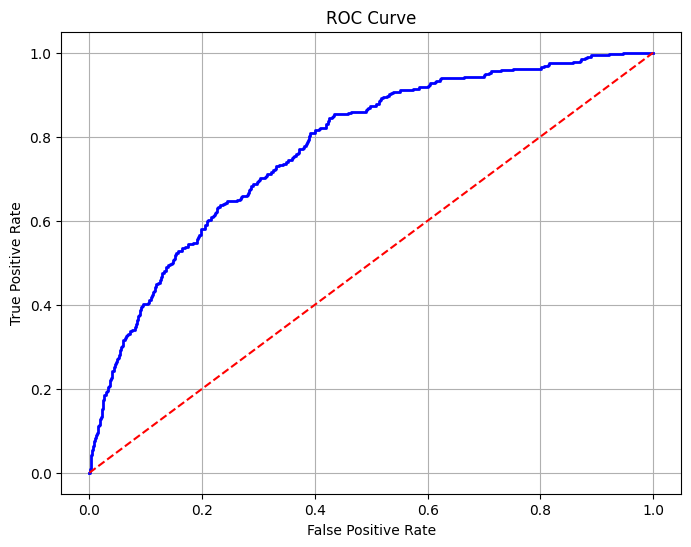

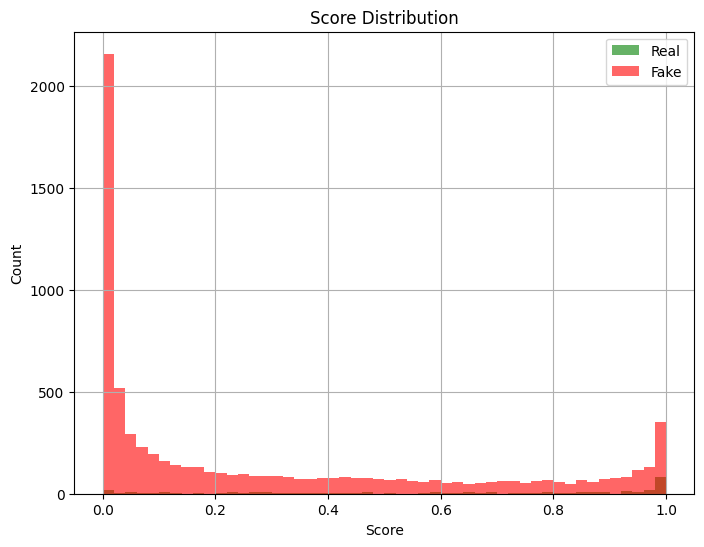

In [4]:
from face_defense.evaluation.visualization import plot_roc_curve, plot_score_distribution

plot_roc_curve(labels, scores)
plot_score_distribution(labels, scores)

## Results

### Silent-FAS Baseline (Pretrained, threshold=0.5)

| Metric | Value |
|--------|-------|
| AUC    | 0.7757 |
| EER    | 0.3032 |
| APCER  | 0.2701 |
| BPCER  | 0.3439 |
| ACER   | 0.3070 |